<div style="background:linear-gradient(135deg,#880e4f,#c2185b,#ad1457);padding:36px 28px;border-radius:14px;color:#fff;text-align:center">
<h1 style="margin:0;font-size:2.3em">🔥 Notebook 2 — CSTR No Isotérmico</h1>
<h2 style="margin:10px 0 4px;font-weight:300">Balance de Energía · Multiplicidad · Estabilidad · Seguridad</h2>
<p style="margin:4px 0 0;opacity:.88">Fogler Capítulos 8 y 9 · 740484 Diseño de Reactores · Universidad del Valle</p>
</div>

---

## 🎯 Objetivos del módulo

1. **Derivar** el balance de energía para el CSTR abierto desde el 1er principio de la termodinámica.
2. **Construir** las curvas $X_{BM}(T)$ y $X_{BE}(T)$ y hallar sus intersecciones (estados estacionarios).
3. **Clasificar** los estados estacionarios usando el **criterio de Van Heerden** (1953).
4. **Identificar** los fenómenos de ignición, extinción e histéresis térmica.
5. **Analizar** el efecto de $UA$, $\tau$, $T_0$ y $T_a$ sobre la multiplicidad.
6. **Calcular** $\Delta T_{ad}$ como indicador de severidad térmica.
7. **Simular** el reactor batch no isotérmico y determinar $t_{mr}$ para análisis de seguridad.

## ⚠️ Relevancia de seguridad de procesos

Los accidentes industriales más graves de la historia reciente involucran pérdida de control térmico en reactores exotérmicos:

| Año | Incidente | Causa |
|-----|-----------|-------|
| 1976 | Seveso (Italia) | Runaway en reactor de triclorofenol |
| 1984 | Bhopal (India) | Reacción exotérmica en tanque de MIC |
| 2007 | T2 Laboratories (USA) | Runaway en reactor de síntesis de MCPD |
| 2013 | West Fertilizer (USA) | Descomposición exotérmica de nitrato de amonio |

La herramienta analítica central para **prevenir** estos accidentes es el análisis de multiplicidad de estados estacionarios y el cálculo de $\Delta T_{ad}$ y $t_{mr}$.

## 📚 Mapa de referencias

| Tema | Sección | Ec. |
|------|---------|-----|
| Balance de energía CSTR | §8.1, Ec. 8-27 | $\dot{Q}+F_{A0}\sum\Theta_iC_{pi}(T_0-T)=F_{A0}\Delta H_{rx}X$ |
| Curvas BM/BE | §8.3 | $X_{BM}=k\tau/(1+k\tau)$ |
| Criterio estabilidad | §8.3.1, Ec. 8-59 | $dR/dT > dG/dT$ estable |
| CSTR adiabático | §8.2, Ec. 8-30 | $T=T_0+\Delta T_{ad}\cdot X$ |
| Batch no isotérmico | §9.1, Ec. 9-9 | ODE acoplada $dT/dt$ |
| Análisis $t_{mr}$ | §9.2 | $d(-r_A)/dt=0$ |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Arc
from matplotlib.patheffects import withStroke
from scipy.optimize import brentq
from scipy.integrate import odeint
from ipywidgets import interact, FloatSlider
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,'axes.grid':True,
    'grid.alpha':0.28,'figure.dpi':110,'axes.titleweight':'bold',
    'lines.linewidth':2.3,'axes.titlesize':11.5,
    'axes.spines.top':False,'axes.spines.right':False,
})
print('✓ Entorno listo')


✓ Entorno listo


---
# 1. Derivación del balance de energía para el CSTR (Fogler §8.1)

## 1.1 1er principio de la termodinámica — sistema abierto, estado estacionario

Para un volumen de control abierto con un flujo de entrada y uno de salida, en estado estacionario (Fogler §8.1, Ec. 8-9):

$$\dot{Q} - \dot{W}_s + \sum_i F_{i0}\hat{H}_{i0} - \sum_i F_i\hat{H}_i = 0$$

donde $\hat{H}_i$ es la entalpía molar de la especie $i$ y $\dot{W}_s$ es el trabajo de eje (usualmente despreciable en reactores).

## 1.2 Expansión de las entalpías

Usando $\hat{H}_i(T) = \hat{H}_{i,\text{ref}} + \int_{T_R}^T C_{p,i}\,dT$:

$$\sum_i F_{i0}\hat{H}_{i0} - \sum_i F_i\hat{H}_i = \underbrace{F_{A0}\sum_i\Theta_i C_{p,i}(T_0-T)}_{\text{cambio de entalpía sensible}} + \underbrace{(-\Delta H_{rx})\,F_{A0}X}_{\text{calor de reacción liberado}}$$

Sustituyendo en el 1er principio (y usando $\dot{Q} = UA(T_a-T)$):

$$\boxed{\dot{Q} = F_{A0}\left[\sum_i\Theta_i C_{p,i}(T-T_0) + \Delta H_{rx}\,X\right]} \tag{8-27}$$

## 1.3 Dos formas de expresar la conversión

La ecuación anterior puede despejarse para X → **balance de energía**:

$$X_{BE}(T) = \frac{\sum_i\Theta_iC_{p,i}(T-T_0) - UA(T_a-T)/F_{A0}}{-\Delta H_{rx}} \tag{BE}$$

La ecuación de diseño con cinética → **balance de masa**:

$$X_{BM}(T) = \frac{k(T)\,\tau}{1+k(T)\,\tau} \tag{BM}$$

## 1.4 Temperatura adiabática de reacción (Fogler §8.2)

Si $\dot{Q}=0$ (adiabático) y expresamos $T$ en función de $X$:

$$\boxed{T = T_0 + \underbrace{\frac{-\Delta H_{rx}\,C_{A0}}{\rho C_p}}_{\Delta T_{ad}}\cdot X}$$

**$\Delta T_{ad}$** es el aumento de temperatura si la reacción adiabática llega a conversión completa ($X=1$). Es el **indicador de severidad** más importante en el diseño de reactores exotérmicos.

| $\Delta T_{ad}$ | Categoría | Ejemplo |
|-----------------|-----------|---------|
| < 50 K | Benigna | Hidrólisis de ésteres |
| 50-200 K | Moderada — **requiere control** | Polimerización acrílica |
| 200-500 K | Alta — sistema de parada obligatorio | Nitración aromática |
| > 500 K | Extrema — peligro de explosión | Descomposición explosivos |


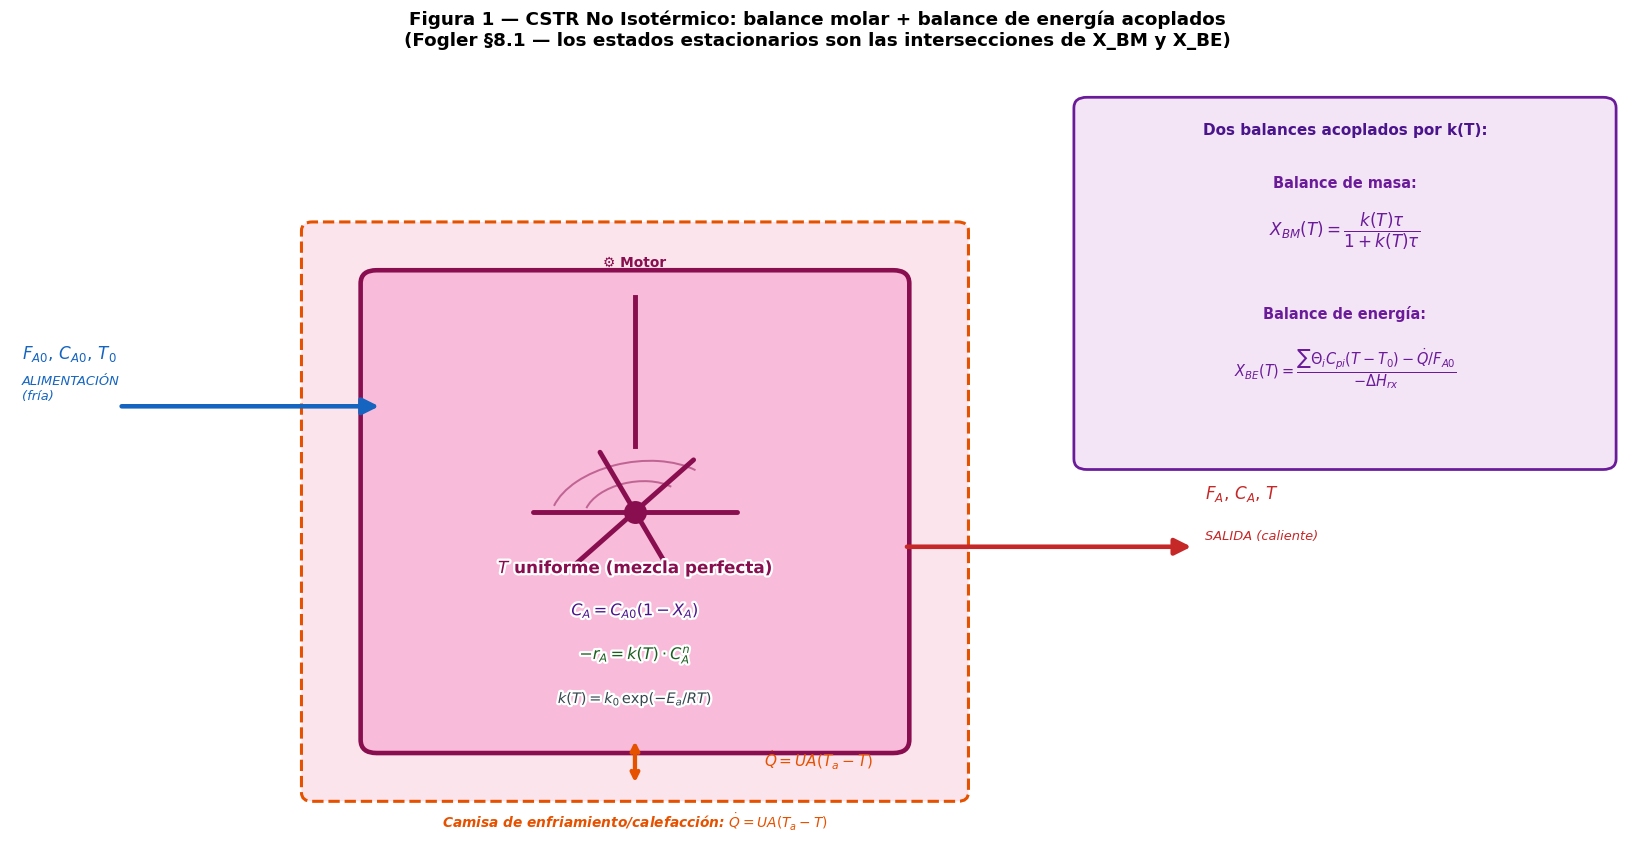

Figura 1 guardada.


In [4]:
import os
# Figura 1: CSTR no isotérmico con camisa — diagrama detallado
pe = [withStroke(linewidth=3, foreground='white')]
fig, ax = plt.subplots(figsize=(15, 8))
ax.set_xlim(0,15); ax.set_ylim(0,9); ax.axis('off')
ax.set_facecolor('#fff5f7')

# Camisa
cam = FancyBboxPatch((2.8,0.7),6.0,6.4,boxstyle='round,pad=0.10',
                     facecolor='#FCE4EC',edgecolor='#E65100',lw=2,ls='--')
ax.add_patch(cam)
ax.text(5.8,0.30,r'Camisa de enfriamiento/calefacción: $\dot{Q}=UA(T_a-T)$',
        ha='center',fontsize=9,color='#E65100',fontweight='bold',style='italic')

# Tanque
tank = FancyBboxPatch((3.4,1.3),4.8,5.2,boxstyle='round,pad=0.15',
                      facecolor='#F8BBD9',edgecolor='#880E4F',lw=3)
ax.add_patch(tank)

# Agitador
cx,cy = 5.8,3.9
ax.plot([cx,cx],[cy+0.75,6.35],color='#880E4F',lw=3.2)
for ang in [0,55,110,180,235,290]:
    ax.plot([cx,cx+0.95*np.cos(np.radians(ang))],
            [cy,cy+0.72*np.sin(np.radians(ang))],
            color='#880E4F',lw=3.2,solid_capstyle='round')
ax.plot(cx,cy,'o',color='#880E4F',ms=14,zorder=6)
for r in [0.48,0.80]:
    arc=Arc((cx,cy),2*r,2*r*0.7,angle=15,theta1=25,theta2=160,
            color='#880E4F',lw=1.3,alpha=0.5)
    ax.add_patch(arc)
ax.text(cx,6.7,'⚙ Motor',ha='center',fontsize=9,color='#880E4F',fontweight='bold')

# Variables internas
ax.text(cx,3.2,r'$T$ uniforme (mezcla perfecta)',ha='center',fontsize=11,
        color='#880E4F',fontweight='bold',path_effects=pe)
ax.text(cx,2.72,r'$C_A = C_{A0}(1-X_A)$',ha='center',fontsize=10.5,
        color='#4A148C',fontweight='bold',path_effects=pe)
ax.text(cx,2.22,r'$-r_A = k(T)\cdot C_A^n$',ha='center',fontsize=10.5,
        color='#1B5E20',fontweight='bold',path_effects=pe)
ax.text(cx,1.72,r'$k(T) = k_0\,\exp(-E_a/RT)$',ha='center',fontsize=9.5,
        color='#37474F',path_effects=pe)

# Entrada
ax.annotate('',xy=(3.45,5.1),xytext=(1.0,5.1),
            arrowprops=dict(arrowstyle='-|>',color='#1565C0',lw=3,mutation_scale=22))
ax.text(0.1,5.65,r'$F_{A0},\,C_{A0},\,T_0$',fontsize=11,color='#1565C0',fontweight='bold')
ax.text(0.1,5.18,'ALIMENTACIÓN\n(fría)',fontsize=8.5,color='#1565C0',style='italic')

# Salida
ax.annotate('',xy=(11.0,3.5),xytext=(8.3,3.5),
            arrowprops=dict(arrowstyle='-|>',color='#C62828',lw=3,mutation_scale=22))
ax.text(11.1,4.05,r'$F_A,\,C_A,\,T$',fontsize=11,color='#C62828',fontweight='bold')
ax.text(11.1,3.58,'SALIDA (caliente)',fontsize=8.5,color='#C62828',style='italic')

# Calor intercambiado
ax.annotate('',xy=(cx,0.78),xytext=(cx,1.32),
            arrowprops=dict(arrowstyle='<->',color='#E65100',lw=2.8))
ax.text(cx+1.2,1.0,r'$\dot{Q}=UA(T_a-T)$',fontsize=10,color='#E65100',fontweight='bold')

# Box ecuaciones
be=FancyBboxPatch((10.0,4.5),4.8,4.0,boxstyle='round,pad=0.12',
                  facecolor='#F3E5F5',edgecolor='#6A1B9A',lw=1.8)
ax.add_patch(be)
ax.text(12.4,8.2,'Dos balances acoplados por k(T):',ha='center',fontsize=10,
        fontweight='bold',color='#4A148C')
ax.text(12.4,7.6,'Balance de masa:',ha='center',fontsize=9.5,color='#6A1B9A',fontweight='bold')
ax.text(12.4,7.05,r'$X_{BM}(T)=\dfrac{k(T)\tau}{1+k(T)\tau}$',ha='center',fontsize=11,color='#6A1B9A')
ax.text(12.4,6.1,'Balance de energía:',ha='center',fontsize=9.5,color='#6A1B9A',fontweight='bold')
ax.text(12.4,5.45,r'$X_{BE}(T)=\dfrac{\sum\Theta_iC_{pi}(T-T_0)-\dot{Q}/F_{A0}}{-\Delta H_{rx}}$',
        ha='center',fontsize=9.5,color='#6A1B9A')

ax.set_title('Figura 1 — CSTR No Isotérmico: balance molar + balance de energía acoplados\n'
             '(Fogler §8.1 — los estados estacionarios son las intersecciones de X_BM y X_BE)',
             fontsize=12,fontweight='bold',pad=12)
plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = '/home/claude/reactores/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'fig_nb2_diagrama.png'),dpi=130,bbox_inches='tight')
plt.show(); print('Figura 1 guardada.')

---
# 2. Fogler Example 8-4: CSTR no isotérmico para propilenglicol

## 2.1 El mismo proceso — sin control isotérmico

En el Example 5-1 (Notebook 1) asumimos control perfecto de temperatura. Ahora **quitamos esa restricción** y dejamos que $T$ flote hasta encontrar el(los) estado(s) estacionario(s) que satisfagan simultáneamente los balances de masa y energía.

## 2.2 Datos (Fogler p. 511)

| Parámetro | Valor | Unidades |
|-----------|-------|----------|
| $k_0$ (pre-exponencial) | 16.96 × 10¹² | h⁻¹ |
| $E_a$ | 32 400 | BTU/lbmol |
| $\Delta H_{rx}$ | −36 400 | BTU/lbmol |
| $\sum\Theta_iC_{p,i}$ | 403 | BTU/(lbmol·R) |
| $UA$ | 35 500 | BTU/(h·R) |
| $T_a$ | 528 R (68°F) | R |
| $\tau$ | 1.0 | h |

## 2.3 Construcción de las curvas

**Para cada $T$ en [520, 660] R**, calcular:
$$k(T) = k_0\,e^{-E_a/(RT)} \quad\Rightarrow\quad X_{BM}(T) = \frac{k\tau}{1+k\tau}$$
$$X_{BE}(T) = \frac{\sum\Theta_iC_{pi}(T-T_0) - UA(T_a-T)/F_{A0}}{-\Delta H_{rx}}$$

## 2.4 Caracterización de los estados estacionarios

| SS | T | X | Tipo | Criterio Van Heerden |
|----|---|---|------|---------------------|
| Bajo | ≈540 R (80°F) | ≈0.06 | **Estable** | $dR/dT > dG/dT$ |
| Medio | ≈580 R (120°F) | ≈0.37 | **INESTABLE** | $dG/dT > dR/dT$ |
| Alto | ≈620 R (160°F) | ≈0.93 | **Estable** | $dR/dT > dG/dT$ |

**Estrategia operacional**: arrancar el reactor con T₀ alta para "saltar" al SS alto. Una vez allí, puede bajarse T₀ siempre que no se cruce el punto de extinción.

## 2.5 Histéresis térmica

Al variar $\tau$ (o $T_0$) gradualmente, el sistema sigue un **camino diferente** según si se incrementa o decrementa el parámetro. Este fenómeno de histéresis tiene consecuencias críticas para:

- **Arranque** del reactor: debe hacerse por la rama adecuada.
- **Parada** de emergencia: bajando $T_0$ puede extinguirse el estado alto súbitamente.
- **Control automático**: el controlador PID puede hacer al sistema oscilar entre ramas si el diseño es inadecuado.


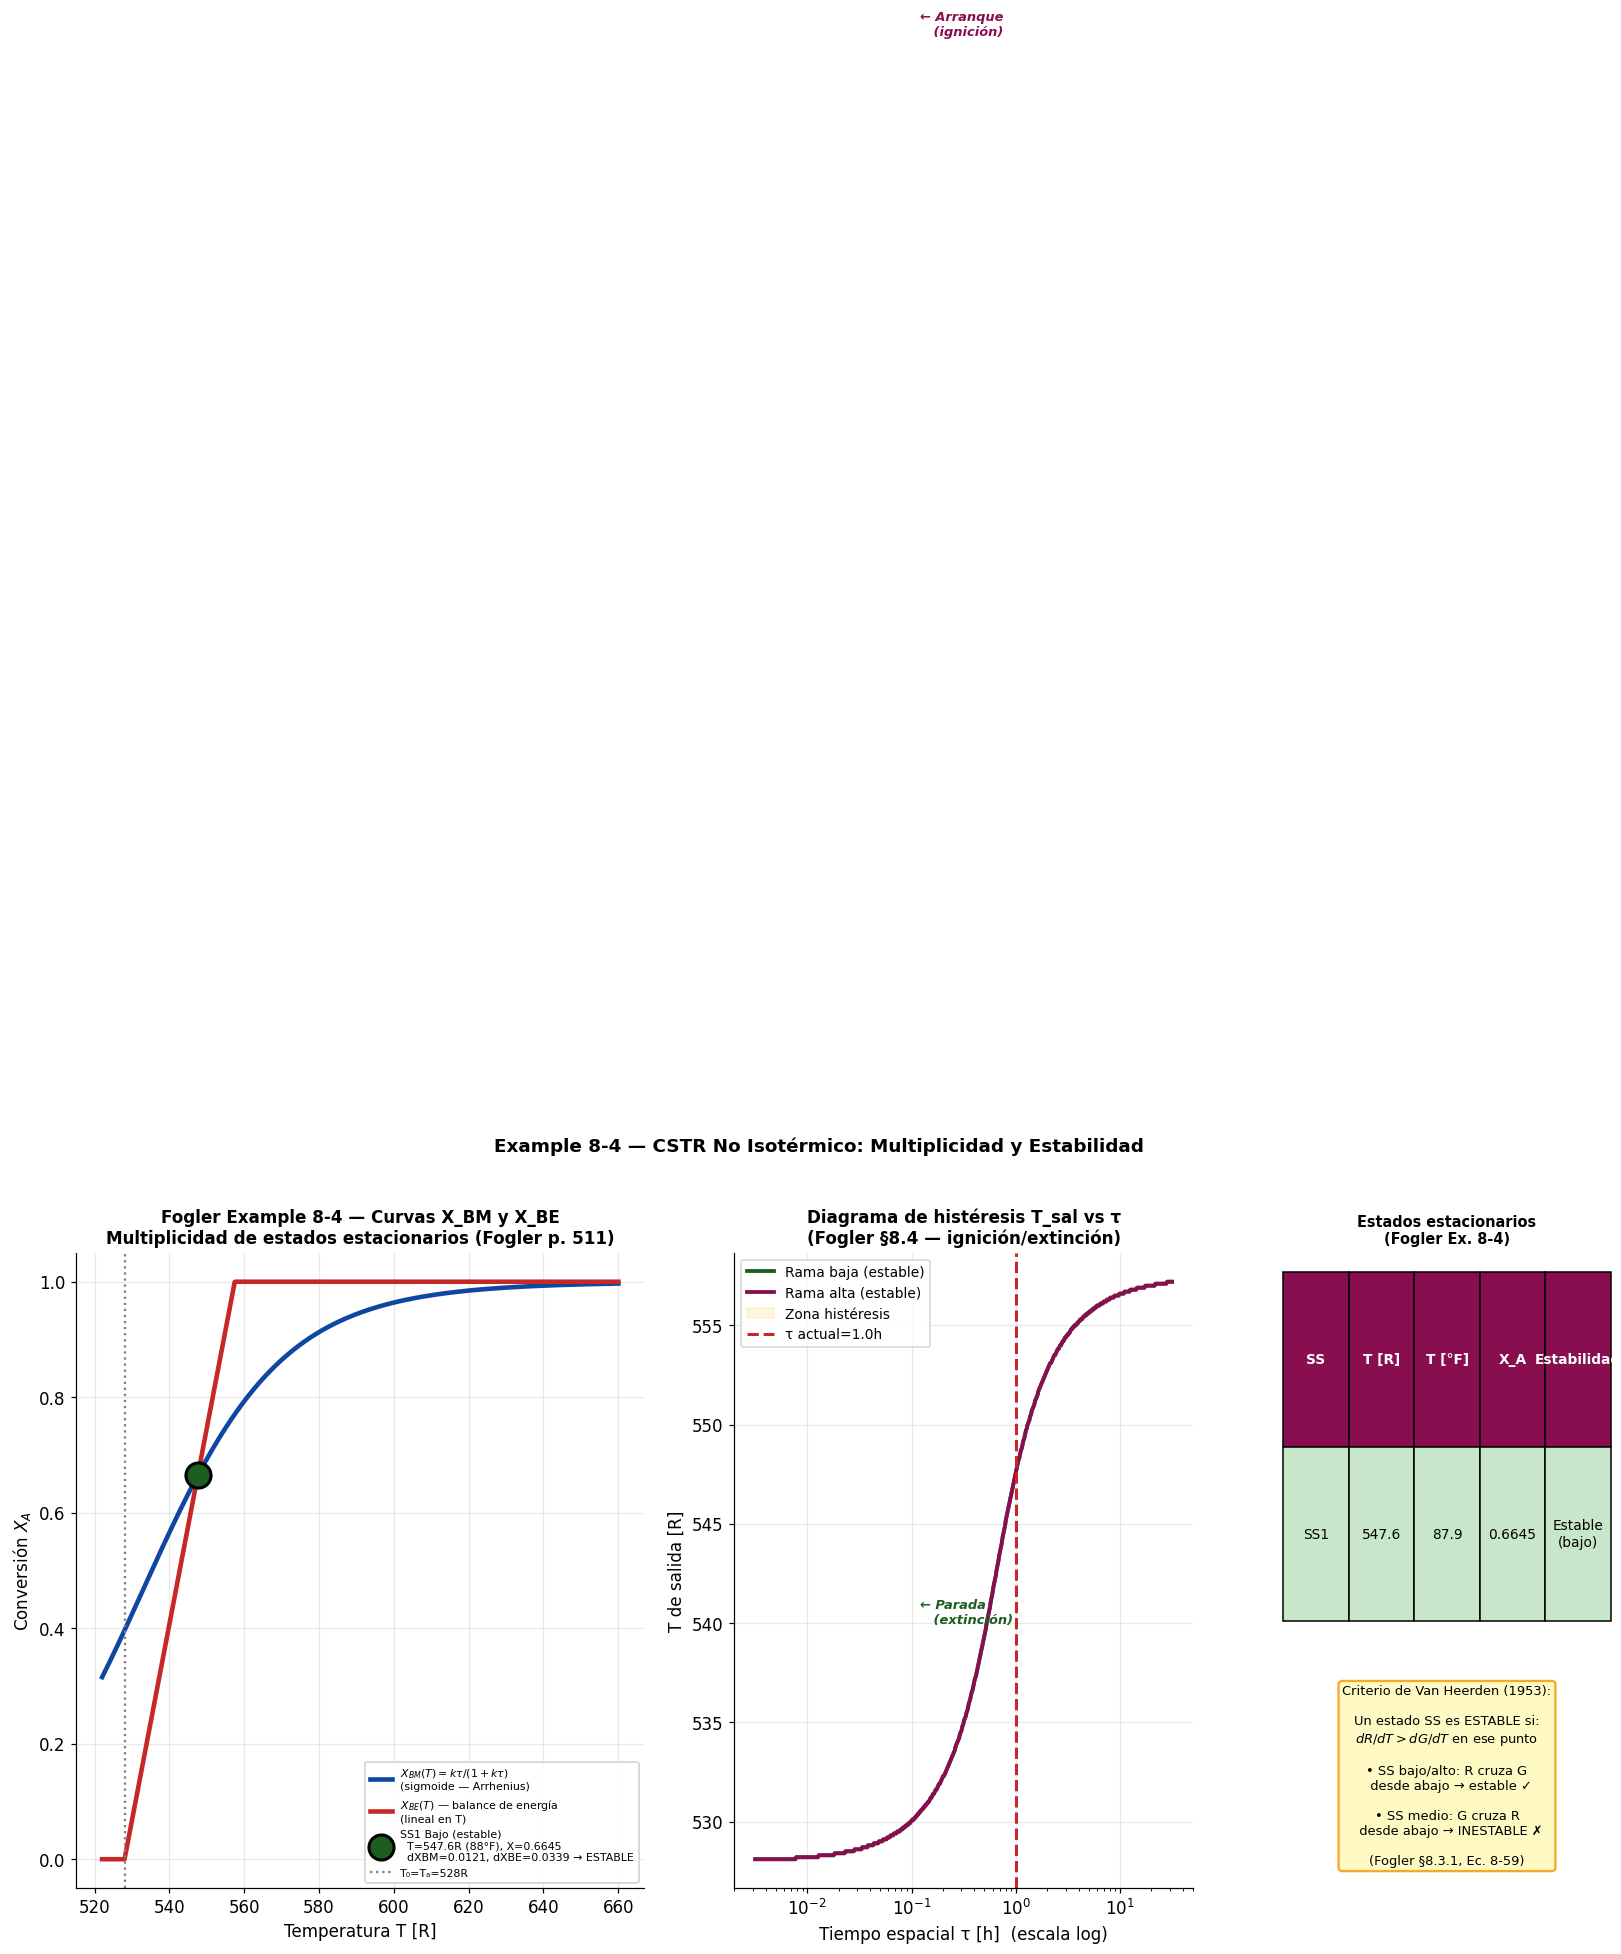


1 estados estacionarios:
  SS1 [Bajo (estable)]: T=547.58R (87.91°F), X=0.6645 → ESTABLE
    dXBM/dT=0.01212 < dXBE/dT=0.03394


In [5]:
# Parámetros Example 8-4
R_gas  = 1.987;  Ea = 32400.;  k0 = 16.96e12
T_ref  = 528.;   dHrx = -36400.;  sumThCp = 403.
CA0    = 0.923;  v0   = 46.2;   FA0 = CA0*v0
UA     = 35500.; Ta   = 528.;   tau = 1.0

def k_T(T): return k0*np.exp(-Ea/(R_gas*T))
def X_BM(T,tau_=tau): return k_T(T)*tau_/(1+k_T(T)*tau_)
def X_BE(T): return (sumThCp*(T-T_ref)-UA*(Ta-T)/FA0)/(-dHrx)

# ── Construcción de curvas ────────────────────────────────────
T_arr = np.linspace(522,660,1200)
Xbm   = np.clip([X_BM(T) for T in T_arr],0,1)
Xbe   = [X_BE(T) for T in T_arr]

# ── Hallar intersecciones ─────────────────────────────────────
diff   = np.array(Xbm) - np.array(Xbe)
puntos = []
for idx in np.where(np.diff(np.sign(diff)))[0]:
    try:
        Ti = brentq(lambda T:X_BM(T)-X_BE(T), T_arr[idx], T_arr[idx+1])
        puntos.append((Ti, X_BM(Ti)))
    except: pass

# ── Derivadas en cada SS (Van Heerden) ───────────────────────
def dXBM_dT(T,tau_=tau):
    k = k_T(T); dkdT = k*Ea/(R_gas*T**2)
    return dkdT*tau_/(1+k*tau_)**2

def dXBE_dT():  # independiente de T
    return (sumThCp + UA/FA0)/(-dHrx)

# ── Figura de 3 paneles ───────────────────────────────────────
fig = plt.figure(figsize=(18,7.5))
gs  = fig.add_gridspec(1,3,width_ratios=[2.6,2.1,1.5])
ax  = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2]); ax3.axis('off')

# ── PANEL 1: Curvas X_BM y X_BE ──────────────────────────────
ax.plot(T_arr,np.clip(Xbm,0,1),'#0D47A1',lw=3,
        label='$X_{BM}(T)=k\\tau/(1+k\\tau)$\n(sigmoide — Arrhenius)')
ax.plot(T_arr,np.clip(Xbe,0,1),'#C62828',lw=3,
        label='$X_{BE}(T)$ — balance de energía\n(lineal en T)')

cols  = ['#1B5E20','#E65100','#880E4F']
tipos = ['Bajo (estable)','Medio (INESTABLE)','Alto (estable)']
mks   = ['o','s','D']
for i,(Tp,Xp) in enumerate(puntos):
    dXBM = dXBM_dT(Tp); dXBE = dXBE_dT()
    stab = 'ESTABLE' if dXBE>dXBM else 'INESTABLE'
    ax.scatter([Tp],[Xp],s=270,color=cols[i%3],zorder=10,
               edgecolors='black',lw=2,marker=mks[i%3],
               label=f'SS{i+1} {tipos[i%3]}\n'
                     f'  T={Tp:.1f}R ({Tp-459.67:.0f}°F), X={Xp:.4f}\n'
                     f'  dXBM={dXBM:.4f}, dXBE={dXBE:.4f} → {stab}')

if len(puntos)==3:
    ax.axvspan(puntos[0][0],puntos[2][0],alpha=0.06,color='orange',
               label='Zona de multiplicidad')
ax.axvline(T_ref,color='gray',ls=':',lw=1.5,label=f'T₀=Tₐ={T_ref:.0f}R')
ax.set_xlabel('Temperatura T [R]',fontsize=11)
ax.set_ylabel('Conversión $X_A$',fontsize=11)
ax.set_title('Fogler Example 8-4 — Curvas X_BM y X_BE\n'
             'Multiplicidad de estados estacionarios (Fogler p. 511)',
             fontsize=11)
ax.legend(fontsize=7.2,loc='lower right',framealpha=0.95)
ax.set_ylim(-0.05,1.05)

# ── PANEL 2: Histéresis — T_sal vs τ ─────────────────────────
tau_arr = np.logspace(-2.5,1.5,500)
T_lo,T_hi = [],[]
for ta in tau_arr:
    xs = []
    for T0g in [535,580,625]:
        try: xs.append(brentq(lambda T:X_BM(T,ta)-X_BE(T),522,680))
        except: pass
    xs = sorted(set([round(x,1) for x in xs]))
    T_lo.append(xs[0] if xs else np.nan)
    T_hi.append(xs[-1] if xs else np.nan)

ax2.semilogx(tau_arr,T_lo,'#1B5E20',lw=2.5,label='Rama baja (estable)')
ax2.semilogx(tau_arr,T_hi,'#880E4F',lw=2.5,label='Rama alta (estable)')
ax2.fill_between(tau_arr,T_lo,T_hi,
                 where=np.array(T_hi)!=np.array(T_lo),
                 alpha=0.12,color='orange',label='Zona histéresis')
ax2.axvline(tau,color='#C62828',ls='--',lw=2,label=f'τ actual={tau}h')
# Anotaciones ignición/extinción
ax2.text(0.12,620,'← Arranque\n   (ignición)',fontsize=8.5,color='#880E4F',
         fontweight='bold',style='italic')
ax2.text(0.12,540,'← Parada\n   (extinción)',fontsize=8.5,color='#1B5E20',
         fontweight='bold',style='italic')
ax2.set_xlabel('Tiempo espacial τ [h]  (escala log)',fontsize=11)
ax2.set_ylabel('T de salida [R]',fontsize=11)
ax2.set_title('Diagrama de histéresis T_sal vs τ\n'
              '(Fogler §8.4 — ignición/extinción)',fontsize=11)
ax2.legend(fontsize=9)

# ── PANEL 3: Tabla estados ─────────────────────────────────────
tipo_rs=['Estable\n(bajo)','INESTABLE\n(punto silla)','Estable\n(alto)']
rows=[['SS','T [R]','T [°F]','X_A','Estabilidad']]
for i,(Tp,Xp) in enumerate(puntos):
    rows.append([f'SS{i+1}',f'{Tp:.1f}',f'{Tp-459.67:.1f}',
                  f'{Xp:.4f}',tipo_rs[i%3]])
tbl=ax3.table(cellText=rows[1:],colLabels=rows[0],
              cellLoc='center',loc='upper center',bbox=[0,0.42,1,0.55])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for j in range(5):
    tbl[0,j].set_facecolor('#880E4F')
    tbl[0,j].set_text_props(color='white',fontweight='bold')
bgs=['#C8E6C9','#FFCCBC','#F8BBD9']
for i in range(1,len(puntos)+1):
    for j in range(5): tbl[i,j].set_facecolor(bgs[(i-1)%3])
# Box criterio Van Heerden
ax3.text(0.5,0.32,
         'Criterio de Van Heerden (1953):\n\n'
         'Un estado SS es ESTABLE si:\n'
         r'$dR/dT > dG/dT$ en ese punto'+'\n\n'
         '• SS bajo/alto: R cruza G\n'
         '  desde abajo → estable ✓\n\n'
         '• SS medio: G cruza R\n'
         '  desde abajo → INESTABLE ✗\n\n'
         '(Fogler §8.3.1, Ec. 8-59)',
         ha='center',va='top',transform=ax3.transAxes,fontsize=8.5,
         bbox=dict(boxstyle='round',facecolor='#FFF9C4',
                   edgecolor='#F9A825',lw=1.5))
ax3.set_title('Estados estacionarios\n(Fogler Ex. 8-4)',
              fontweight='bold',fontsize=9.5)

plt.suptitle('Example 8-4 — CSTR No Isotérmico: Multiplicidad y Estabilidad',
             fontsize=12,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('/home/claude/reactores/fig_nb2_ex84.png',dpi=115,bbox_inches='tight')
plt.show()
print(f'\n{len(puntos)} estados estacionarios:')
for i,(Tp,Xp) in enumerate(puntos):
    dXBM=dXBM_dT(Tp); dXBE=dXBE_dT()
    stab='ESTABLE' if dXBE>dXBM else 'INESTABLE'
    print(f'  SS{i+1} [{tipos[i%3]}]: T={Tp:.2f}R ({Tp-459.67:.2f}°F), X={Xp:.4f} → {stab}')
    print(f'    dXBM/dT={dXBM:.5f} {"<" if dXBE>dXBM else ">"} dXBE/dT={dXBE:.5f}')


---
# 3. Curvas G(T) y R(T) — Criterio de Van Heerden (Fogler §8.3)

## 3.1 Reformulación del balance de energía en términos de calor

El balance de energía puede separarse en dos términos con unidades de [BTU/(lbmol A)]:

$$\underbrace{G(T) = (-\Delta H_{rx})\cdot X_{BM}(T)}_{\text{calor GENERADO por reacción}} = \underbrace{R(T) = \sum\Theta_iC_{pi}(T-T_0) + \frac{UA}{F_{A0}}(T-T_a)}_{\text{calor REMOVIDO por corriente + camisa}}$$

## 3.2 Propiedades geométricas de las curvas

| Función | Forma | Parámetros que la controlan |
|---------|-------|---------------------------|
| $G(T)$ | **Sigmoide** (creciente hasta plateau $-\Delta H_{rx}$) | $\tau$, $k_0$, $E_a$ — *fija para un $\tau$ dado* |
| $R(T)$ | **Línea recta** con pendiente $= \sum\Theta_iC_{pi} + UA/F_{A0}$ | $UA$, $T_a$, $T_0$ — *ajustable por el operador* |

## 3.3 Criterio de estabilidad formal (Van Heerden, 1953)

Para analizar la estabilidad, considere una perturbación $\delta T > 0$ desde un SS:

- Si $R$ sube más rápido que $G$: el calor removido excede el generado → T regresa → **ESTABLE**
- Si $G$ sube más rápido que $R$: el calor generado excede el removido → T se dispara → **INESTABLE**

Matemáticamente, el SS es **estable** si y sólo si:

$$\boxed{\left.\frac{dR}{dT}\right|_{SS} > \left.\frac{dG}{dT}\right|_{SS}}$$

El SS **medio** (de los tres) siempre viola esta condición → es un punto de silla termodinámicamente inestable.

## 3.4 Ingeniería del parámetro UA

El parámetro $UA$ es la herramienta del ingeniero para eliminar o controlar la multiplicidad:

- **$UA$ pequeño** (camisa ineficiente): $R(T)$ tiene pendiente baja → 3 intersecciones posibles.
- **$UA$ grande** (camisa eficiente): $R(T)$ tiene pendiente alta → posiblemente 1 sola intersección.
- **Valor crítico** $UA_\text{crit}$: cuando la recta $R$ es tangente a la curva $G$ → transición de multiplicidad a estado único.

**Diseño recomendado**: operar con $UA > UA_\text{crit}$ para garantizar un único estado estacionario. Si por razones económicas $UA < UA_\text{crit}$, implementar controladores anti-windup con límites de temperatura explícitos.

## 3.5 Explore la multiplicidad con el widget


In [6]:
def plot_GR(tau_h=1.0, UA_v=35500., Ta_v=528., T0_v=528.):
    T_ar  = np.linspace(519,692,1200)
    Xbm_  = np.array([X_BM(T,tau_h) for T in T_ar])
    G_ar  = (-dHrx)*Xbm_
    R_ar  = sumThCp*(T_ar-T0_v) + UA_v/FA0*(T_ar-Ta_v)

    diff2 = G_ar - R_ar
    pts2  = []
    for idx in np.where(np.diff(np.sign(diff2)))[0]:
        try:
            Ti = brentq(lambda T:(-dHrx)*X_BM(T,tau_h)
                        -(sumThCp*(T-T0_v)+UA_v/FA0*(T-Ta_v)),
                        T_ar[idx],T_ar[idx+1])
            pts2.append(Ti)
        except: pass

    def dG_dT(T):
        k = k_T(T); dkdT = k*Ea/(R_gas*T**2)
        return (-dHrx)*dkdT*tau_h/(1+k*tau_h)**2
    def dR_dT(): return sumThCp + UA_v/FA0

    fig,axes = plt.subplots(1,2,figsize=(16,7))

    # ── Panel 1: G(T) vs R(T) ────────────────────────────────
    ax = axes[0]
    ax.plot(T_ar,G_ar,'#C62828',lw=3,
            label='G(T) = $(-\\Delta H_{rx})\\cdot X_{BM}(T)$\n'
                  '(calor generado — sigmoide)')
    ax.plot(T_ar,R_ar,'#0D47A1',lw=3,
            label=f'R(T) = $\\sum\\Theta_iC_{{pi}}(T-T_0)+UA(T-T_a)/F_{{A0}}$\n'
                  f'(calor removido — recta, pendiente={dR_dT():.0f})')
    ax.fill_between(T_ar,G_ar,R_ar,where=(G_ar>R_ar),
                    alpha=0.14,color='#C62828',label='G>R → T sube (ignición)')
    ax.fill_between(T_ar,G_ar,R_ar,where=(R_ar>G_ar),
                    alpha=0.10,color='#0D47A1',label='R>G → T baja (extinción)')

    cols3=['#1B5E20','#E65100','#880E4F']
    tipos3=['Estable bajo','INESTABLE','Estable alto']
    mks3=['o','s','D']
    for i,Ti in enumerate(pts2):
        Gi = (-dHrx)*X_BM(Ti,tau_h)
        dG = dG_dT(Ti); dR = dR_dT()
        stab = '✓ESTABLE' if dR>dG else '✗INESTABLE'
        ax.scatter([Ti],[Gi],s=270,color=cols3[i%3],zorder=10,
                   edgecolors='black',lw=2,marker=mks3[i%3],
                   label=f'{tipos3[i%3]}: T={Ti:.0f}R\n'
                         f'  dG={dG:.0f} vs dR={dR:.0f} → {stab}')
    ax.set_xlabel('Temperatura T [R]',fontsize=11)
    ax.set_ylabel('[BTU/(lbmol A)]',fontsize=11)
    ax.set_title(f'G(T) vs R(T) — Criterio de Van Heerden\n'
                 f'τ={tau_h:.2f}h, UA={UA_v:.0f}, Tₐ={Ta_v:.0f}R, T₀={T0_v:.0f}R',
                 fontsize=11)
    ax.legend(fontsize=7.5,loc='upper left',framealpha=0.95)

    # ── Panel 2: Efecto de UA sobre la multiplicidad ──────────
    ax2 = axes[1]
    UA_vals=[0,5000,20000,35500,70000,130000]
    cols_UA=plt.cm.Blues(np.linspace(0.2,0.95,len(UA_vals)))
    for ua_i,c_i in zip(UA_vals,cols_UA):
        R_i = sumThCp*(T_ar-T0_v) + ua_i/FA0*(T_ar-Ta_v)
        lbl = f'UA={ua_i:,}' + (' ← actual' if ua_i==UA_v else '')
        ax2.plot(T_ar,R_i,color=c_i,lw=2.2 if ua_i!=UA_v else 3,
                 ls='--' if ua_i==UA_v else '-',label=lbl)
    ax2.plot(T_ar,G_ar,'#C62828',lw=3.5,label='G(T) — no cambia con UA')
    # Marcar tangente (aprox)
    ax2.set_xlabel('Temperatura T [R]',fontsize=11)
    ax2.set_ylabel('[BTU/(lbmol A)]',fontsize=11)
    ax2.set_title('Efecto de UA sobre R(T)\n'
                  'Mayor UA → mayor pendiente → menos intersecciones',
                  fontsize=11)
    ax2.legend(fontsize=8,loc='upper left')

    plt.suptitle(f'Análisis G(T) vs R(T) — Estabilidad térmica del CSTR',
                 fontsize=12,fontweight='bold',y=1.02)
    plt.tight_layout(); plt.show()
    print(f'  Estados estacionarios: {len(pts2)}')
    for i,Ti in enumerate(pts2):
        dG=dG_dT(Ti); dR=dR_dT()
        stab='ESTABLE' if dR>dG else 'INESTABLE'
        print(f'    SS{i+1}: T={Ti:.1f}R ({Ti-459.67:.1f}°F), X={X_BM(Ti,tau_h):.4f}'
              f' [dG={dG:.0f} {"<" if dR>dG else ">"} dR={dR:.0f} → {stab}]')

interact(plot_GR,
    tau_h =FloatSlider(value=1.0,min=0.01,max=8.0,step=0.05,
                       description='τ [h]',style={'description_width':'120px'}),
    UA_v  =FloatSlider(value=35500,min=0,max=150000,step=1000,
                       description='UA [BTU/h·R]',style={'description_width':'120px'}),
    Ta_v  =FloatSlider(value=528,min=490,max=580,step=2,
                       description='Tₐ [R]',style={'description_width':'120px'}),
    T0_v  =FloatSlider(value=528,min=490,max=580,step=2,
                       description='T₀ [R]',style={'description_width':'120px'})
);


interactive(children=(FloatSlider(value=1.0, description='τ [h]', max=8.0, min=0.01, step=0.05, style=SliderSt…

---
# 4. CSTR adiabático — la línea adiabática (Fogler §8.2)

## 4.1 Caso límite $\dot{Q}=0$

Para el CSTR sin intercambio de calor ($UA=0$), el balance de energía colapsa a:

$$F_{A0}\sum\Theta_iC_{p,i}(T-T_0) = (-\Delta H_{rx})\,F_{A0}\,X$$

$$\implies T = T_0 + \Delta T_{ad}\cdot X \quad\text{con}\quad \Delta T_{ad} = \frac{-\Delta H_{rx}\,C_{A0}}{\rho\,C_p}$$

Esta es la **línea adiabática**: relación lineal entre T y X con pendiente $\Delta T_{ad}$ e intercepto $T_0$.

## 4.2 Sensibilidad: efecto del $\Delta T_{ad}$ sobre el diseño

Para el mismo $\tau$, un mayor $\Delta T_{ad}$ implica:
- Mayor $T_\text{sal}$ → mayor $k(T_\text{sal})$ → mayor conversión (si no hay limitaciones de equilibrio).
- Mayor riesgo de fallo del material de construcción ($T > T_\text{diseño,max}$).
- Mayor posibilidad de multiplicidad de estados.

## 4.3 Curva de ignición adiabática

Al barrer $\tau$ desde 0 hasta $\infty$, la temperatura de salida describe una curva sigmoidea que puede presentar saltos abruptos (ignición/extinción) en presencia de multiplicidad.


In [7]:
R_SI=8.314e-3; k0_SI=7.08e10; Ea_SI=75.36
def k_SI(T): return k0_SI*np.exp(-Ea_SI/(R_SI*T))

def plot_adia(tau_min=5.0,T0_K=300.,dH_kJ=-80.,Cp_kj=0.167):
    dTad    = (-dH_kJ)/Cp_kj
    T_max_t = T0_K+dTad
    T_scan  = np.linspace(T0_K,min(T_max_t*1.04,T0_K+1500),800)
    Xbm_    = np.array([k_SI(T)*tau_min/(1+k_SI(T)*tau_min) for T in T_scan])
    Xbe_    = np.clip((T_scan-T0_K)/dTad,0,1)

    diff=Xbm_-Xbe_
    pts_a=[]
    for idx in np.where(np.diff(np.sign(diff)))[0]:
        try:
            Ti=brentq(lambda T:k_SI(T)*tau_min/(1+k_SI(T)*tau_min)-(T-T0_K)/dTad,
                      T_scan[idx],T_scan[idx+1])
            pts_a.append((Ti,k_SI(Ti)*tau_min/(1+k_SI(Ti)*tau_min)))
        except: pass

    fig,axes=plt.subplots(1,3,figsize=(17,6))

    # Panel 1: BM vs línea adiabática
    ax=axes[0]
    ax.plot(T_scan,np.clip(Xbm_,0,1),'#0D47A1',lw=3,
            label=r'$X_{BM}(T)$ — sigmoide cinética')
    ax.plot(T_scan,Xbe_,'#C62828',lw=3,ls='--',
            label=r'Línea adiabática: $X=(T-T_0)/\Delta T_{ad}$')
    ax.axvline(T0_K,color='gray',ls=':',lw=1.5,label=f'T₀={T0_K:.0f}K')
    ax.axvline(T_max_t,color='orange',ls=':',lw=1.5,
               label=f'T₀+ΔT_ad={T_max_t:.0f}K')
    cols_a=['#1B5E20','#E65100','#880E4F']
    for i,(Ti,Xi) in enumerate(pts_a):
        ax.scatter([Ti],[Xi],s=260,color=cols_a[i%3],zorder=10,
                   edgecolors='black',lw=2,
                   label=f'SS{i+1}: T={Ti:.1f}K, X={Xi:.3f}')
    ax.set_xlabel('Temperatura [K]'); ax.set_ylabel('$X_A$')
    ax.set_title(f'CSTR Adiabático — τ={tau_min:.1f}min\n'
                 f'ΔT_ad={dTad:.1f}K  (Fogler §8.2)')
    ax.legend(fontsize=8.5,loc='upper left'); ax.set_ylim(-0.05,1.05)

    # Panel 2: T_sal y X vs τ
    tau_sc=np.logspace(-1,2.5,400); T_op,X_op=[],[]
    for ti in tau_sc:
        try:
            Ts=brentq(lambda T:k_SI(T)*ti/(1+k_SI(T)*ti)-(T-T0_K)/dTad,
                      T0_K+0.01,T_max_t*0.9995)
            T_op.append(Ts); X_op.append(k_SI(Ts)*ti/(1+k_SI(Ts)*ti))
        except: T_op.append(np.nan); X_op.append(np.nan)
    ax2=axes[1]
    l1,=ax2.semilogx(tau_sc,T_op,'#C62828',lw=2.8,label='T salida [K]')
    ax2b=ax2.twinx()
    l2,=ax2b.semilogx(tau_sc,X_op,'#0D47A1',lw=2.5,ls='--',label='X_A salida')
    ax2.axvline(tau_min,color='gray',ls=':',lw=2,label=f'τ actual')
    ax2.set_xlabel('τ [min]  (log)'); ax2.set_ylabel('T salida [K]',color='#C62828')
    ax2b.set_ylabel('$X_A$ salida',color='#0D47A1'); ax2b.set_ylim(0,1)
    ax2.set_title('Curva de ignición: T y X vs τ\n(histéresis si multiplicidad)')
    ax2.legend(handles=[l1,l2],fontsize=9)

    # Panel 3: X_sal vs ΔH_rx
    dH_vals=np.linspace(-15,-230,100); X_fin=[]
    for dhi in dH_vals:
        dTi=(-dhi)/Cp_kj
        try:
            Ts=brentq(lambda T:k_SI(T)*tau_min/(1+k_SI(T)*tau_min)-(T-T0_K)/dTi,
                      T0_K+0.01,T0_K+dTi*0.9995)
            X_fin.append(k_SI(Ts)*tau_min/(1+k_SI(Ts)*tau_min))
        except: X_fin.append(np.nan)
    ax3=axes[2]
    ax3.plot(dH_vals,X_fin,'#0D47A1',lw=2.8)
    ax3.axvline(dH_kJ,color='#C62828',ls='--',lw=2.2,label=f'ΔH={dH_kJ:.0f}kJ/mol')
    ax3.fill_between(dH_vals,0,np.nan_to_num(X_fin),alpha=0.15,color='#0D47A1')
    ax3.set_xlabel('ΔH_rx [kJ/mol]'); ax3.set_ylabel('X salida')
    ax3.set_title(f'Sensibilidad X vs ΔH\n(τ={tau_min:.1f}min, T₀={T0_K:.0f}K fijos)')
    ax3.legend(fontsize=9)

    plt.suptitle(f'CSTR Adiabático — ΔT_ad={dTad:.1f}K | τ={tau_min:.1f}min | T₀={T0_K:.0f}K',
                 fontsize=12,fontweight='bold',y=1.02)
    plt.tight_layout(); plt.show()
    print(f'  ΔT_ad={dTad:.1f}K | T_max_adiabática={T_max_t:.1f}K ({T_max_t-273.15:.1f}°C)')
    for i,(Ti,Xi) in enumerate(pts_a):
        print(f'  SS{i+1}: T={Ti:.2f}K ({Ti-273.15:.2f}°C), X={Xi:.4f}')

interact(plot_adia,
    tau_min=FloatSlider(value=5.,min=0.1,max=80.,step=0.5,
                        description='τ [min]',style={'description_width':'110px'}),
    T0_K   =FloatSlider(value=300.,min=270.,max=340.,step=2.,
                        description='T₀ [K]',style={'description_width':'110px'}),
    dH_kJ  =FloatSlider(value=-80.,min=-250.,max=-5.,step=5.,
                        description='ΔH [kJ/mol]',style={'description_width':'110px'}),
    Cp_kj  =FloatSlider(value=0.167,min=0.05,max=0.5,step=0.01,
                        description='Cp [kJ/mol·K]',style={'description_width':'110px'})
);


interactive(children=(FloatSlider(value=5.0, description='τ [min]', max=80.0, min=0.1, step=0.5, style=SliderS…

---
# 5. Reactor Batch No Isotérmico — Fogler §9.1-§9.2

## 5.1 ODEs acopladas: el núcleo del problema

Para el reactor batch con reacción exotérmica (Fogler Ec. 9-9 y 9-10):

$$\frac{dX}{dt} = k(T)(1-X) \qquad \text{[balance de masa — 1er orden]}$$

$$\frac{dT}{dt} = \frac{UA(T_a-T) + (-\Delta H_{rx})\cdot(-r_A)\cdot V}{\sum N_i C_{p,i}} \qquad \text{[balance de energía]}$$

El **acoplamiento** es exponencial: $k(T) = k_0 e^{-E_a/RT}$ aparece en ambas ecuaciones.

## 5.2 Tiempo de máxima velocidad $t_{mr}$ — herramienta de seguridad

El tiempo al que la velocidad de reacción es **máxima** (Fogler §9.2):

$$t_{mr} \;:\; \frac{d(-r_A)}{dt} = 0$$

**Significado operacional crítico**:

| Evento | Consecuencia si $\dot{Q}_\text{falla}$ |
|--------|----------------------------------------|
| Falla **antes** de $t_{mr}$ | La reacción aún se acelera → T puede dispararse sin control |
| Falla **después** de $t_{mr}$ | La reacción se desacelera por agotamiento → T se estabiliza sola |

**Estándar industrial**: para transporte de mezclas reactivas, las regulaciones ATEX exigen $t_{mr,\text{adiabático}} > 24\,\text{h}$ a la temperatura máxima de transporte.

## 5.3 Tres escenarios canónicos de operación

1. **Adiabático ($UA=0$)**: T sube hasta $T_0 + \Delta T_{ad}$ si la reacción llega a completarse. El espacio de fase $(X,T)$ sigue la línea adiabática exactamente.

2. **Enfriamiento insuficiente ($UA < UA_\text{crit}$)**: T sube pero se estabiliza en algún punto. La conversión final es menor que en el caso isotérmico.

3. **Control isotérmico perfecto ($UA\to\infty$)**: T = constante = $T_0$. La conversión sigue la cinética pura $X(t) = 1-e^{-kt}$.


In [8]:
R_b=8.314e-3; k0_b=7.08e10; Ea_b0=75.36; CA0_b=2.0; CpA_b=0.167; V_b=5.0

def plot_batch(dH_b=-80.,UA_b=0.,Ta_b=320.,T0_b=300.,Ea_show=75.36,t_max=120.):
    NA0 = CA0_b*V_b
    def k_b(T): return k0_b*np.exp(-Ea_show/(R_b*T))
    def odes(y,t_):
        X_,T_ = y
        X_=max(0,min(X_,0.9999)); T_=max(T_,250)
        CA=CA0_b*(1-X_); rA=k_b(T_)*CA
        dX=rA/CA0_b
        dT=(UA_b*(Ta_b-T_)/1000+(-dH_b)*rA*V_b)/(NA0*CpA_b)
        return [dX,dT]

    t_=np.linspace(0,t_max,4000)
    ci_data=[(T0_b,'#0D47A1','-',f'T₀={T0_b:.0f}K (nominal)'),
             (T0_b+8,'#C62828','--',f'T₀+8K'),
             (T0_b-8,'#2E7D32',':',f'T₀−8K')]
    sols=[(odeint(odes,[0.,Ti],t_),c,ls,lbl) for Ti,c,ls,lbl in ci_data]

    sol0,_,_,_=sols[0]
    X0=np.clip(sol0[:,0],0,1); T0a=sol0[:,1]
    rA_arr=np.array([k_b(T0a[i])*CA0_b*(1-X0[i]) for i in range(len(t_))])
    idx_mr=np.argmax(rA_arr); t_mr=t_[idx_mr]; T_mr=T0a[idx_mr]
    dTad=(-dH_b)/(CpA_b*1000)*CA0_b

    fig,axes=plt.subplots(2,2,figsize=(16,11))
    fig.suptitle(f'Batch No Isotérmico — ΔH={dH_b}kJ/mol, UA={UA_b:.0f}W/K, '
                 f'Eₐ={Ea_show:.1f}kJ/mol | ΔT_ad={dTad:.1f}K',
                 fontsize=12,fontweight='bold',y=1.01)

    # (0,0) X(t)
    for sol,c,ls,lbl in sols:
        X_=np.clip(sol[:,0],0,1)
        axes[0,0].plot(t_,X_,color=c,ls=ls,lw=2.3,label=lbl)
    axes[0,0].axhline(0.90,color='gold',ls='--',lw=1.8,label='X=0.90')
    axes[0,0].axvline(t_mr,color='#6A1B9A',ls=':',lw=2,label=f't_mr={t_mr:.1f}min')
    axes[0,0].set_xlabel('t [min]'); axes[0,0].set_ylabel('$X_A$')
    axes[0,0].set_title('Conversión vs tiempo\n(sensibilidad a T₀ inicial)')
    axes[0,0].legend(fontsize=9); axes[0,0].set_ylim(0,1.05)

    # (0,1) T(t)
    for sol,c,ls,lbl in sols:
        T_=sol[:,1]; axes[0,1].plot(t_,T_,color=c,ls=ls,lw=2.3,label=lbl)
    axes[0,1].axhline(T0_b,color='gray',ls=':',lw=1.5,label=f'T₀={T0_b:.0f}K')
    axes[0,1].axhline(T0_b+dTad,color='#C62828',ls=':',lw=1.3,
                      label=f'T_max_ad={T0_b+dTad:.0f}K')
    if UA_b>0:
        axes[0,1].axhline(Ta_b,color='orange',ls='-.',lw=1.5,label=f'Tₐ={Ta_b:.0f}K')
    axes[0,1].axvline(t_mr,color='#6A1B9A',ls=':',lw=2,label=f't_mr={t_mr:.1f}min')
    axes[0,1].set_xlabel('t [min]'); axes[0,1].set_ylabel('T [K]')
    axes[0,1].set_title('Perfil de temperatura\n(análisis térmico de seguridad)')
    axes[0,1].legend(fontsize=8.5)

    # (1,0) Espacio de fase X-T
    for sol,c,ls,lbl in sols:
        X_=np.clip(sol[:,0],0,1); T_=sol[:,1]
        axes[1,0].plot(T_,X_,color=c,ls=ls,lw=2.3,label=lbl)
    if UA_b<1e-2:
        Xr=np.linspace(0,1,80)
        axes[1,0].plot(T0_b+dTad*Xr,Xr,'orange',ls='--',lw=2,alpha=0.85,
                       label=f'Línea adiabática ΔT_ad={dTad:.1f}K')
    axes[1,0].scatter([T0_b],[0],color='#2E7D32',s=160,zorder=9,
                      edgecolors='black',lw=1.5,label='Inicio')
    axes[1,0].scatter([T0a[-1]],[X0[-1]],color='#C62828',s=160,zorder=9,
                      edgecolors='black',lw=1.5,label=f'Final X={X0[-1]:.3f}')
    axes[1,0].set_xlabel('T [K]'); axes[1,0].set_ylabel('$X_A$')
    axes[1,0].set_title('Espacio de fase X-T\n(trayectoria dinámica del sistema)')
    axes[1,0].legend(fontsize=9)

    # (1,1) Velocidad -r_A con t_mr
    axes[1,1].plot(t_,rA_arr,'#6A1B9A',lw=3)
    axes[1,1].axvline(t_mr,color='#C62828',ls='--',lw=2.5,
                      label=f'$t_{{mr}}$ = {t_mr:.1f} min')
    axes[1,1].scatter([t_mr],[rA_arr[idx_mr]],s=220,color='#C62828',
                       zorder=9,edgecolors='black',lw=2)
    axes[1,1].fill_between(t_[:idx_mr+1],0,rA_arr[:idx_mr+1],
                            alpha=0.22,color='#C62828',
                            label='FASE CRÍTICA: aceleración\n(falla del enfriamiento = runaway)')
    axes[1,1].fill_between(t_[idx_mr:],0,rA_arr[idx_mr:],
                            alpha=0.15,color='#2E7D32',
                            label='FASE SEGURA: desaceleración')
    axes[1,1].set_xlabel('t [min]'); axes[1,1].set_ylabel('$-r_A$ [mol/(L·min)]')
    axes[1,1].set_title(f'Velocidad de reacción — $t_{{mr}}$ = {t_mr:.1f} min\n'
                         '(Fogler §9.2 — tiempo al máximo de velocidad)')
    axes[1,1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('/home/claude/reactores/fig_nb2_batch.png',dpi=110,bbox_inches='tight')
    plt.show()
    print(f'  T_max = {T0a.max():.2f}K ({T0a.max()-273.15:.2f}°C)')
    print(f'  ΔT_ad = {dTad:.1f}K → T_max_ad = {T0_b+dTad:.1f}K')
    print(f'  t_mr  = {t_mr:.2f}min = {t_mr/60:.4f}h')
    print(f'  X_en_t_mr = {X0[idx_mr]:.4f}')
    print(f'  X_final   = {X0[-1]:.4f}')
    crit='ALTA — runaway posible' if (UA_b<1 and dTad>150) else 'MODERADA' if dTad>50 else 'BAJA'
    print(f'  Criticidad: {crit}')

interact(plot_batch,
    dH_b    =FloatSlider(value=-80.,min=-250.,max=-5.,step=5.,
                         description='ΔH [kJ/mol]',style={'description_width':'140px'}),
    UA_b    =FloatSlider(value=0.,min=0.,max=800.,step=20.,
                         description='UA [W/K]',style={'description_width':'140px'}),
    Ta_b    =FloatSlider(value=320.,min=280.,max=380.,step=2.,
                         description='Tₐ [K]',style={'description_width':'140px'}),
    T0_b    =FloatSlider(value=300.,min=275.,max=340.,step=2.,
                         description='T₀ [K]',style={'description_width':'140px'}),
    Ea_show =FloatSlider(value=75.36,min=20.,max=150.,step=2.,
                         description='Eₐ [kJ/mol]',style={'description_width':'140px'}),
    t_max   =FloatSlider(value=120.,min=10.,max=600.,step=10.,
                         description='t_max [min]',style={'description_width':'140px'})
);


interactive(children=(FloatSlider(value=-80.0, description='ΔH [kJ/mol]', max=-5.0, min=-250.0, step=5.0, styl…

---
# 🎓 Resumen y conexión con el programa

## Conceptos clave de este módulo

| Concepto | Resultado central |
|----------|------------------|
| Balance de energía CSTR | $\dot{Q} = F_{A0}[\sum\Theta_iC_{pi}(T-T_0) + \Delta H_{rx}X]$ |
| Multiplicidad | Hasta 3 intersecciones de $X_{BM}$ y $X_{BE}$ para $\Delta H_{rx}<0$ |
| Criterio de Van Heerden | SS estable ↔ $dR/dT > dG/dT$ |
| Histéresis | Camino de ignición ≠ camino de extinción |
| CSTR adiabático | $T = T_0 + \Delta T_{ad}\cdot X$ — caso límite $UA=0$ |
| $\Delta T_{ad}$ | Indicador de severidad térmica; >200K requiere sistemas de parada |
| $t_{mr}$ | Tiempo al máximo de velocidad — referencia para sistemas de emergencia |

## Próximos módulos

- **Notebook 3**: PFR isotérmico y no isotérmico — integración numérica de ODEs, caída de presión, selectividad en paralelo/serie.
- **Notebook 4**: Reactor Batch — métodos integral y diferencial para cinética, diseño de lotes, análisis cuantitativo de seguridad.

---
*Notebook 2 — Programa 740484 · Maestría Ingeniería Química · Universidad del Valle · 2024*
